In [1]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
#load Dataset / Set Theme
# Set Seaborn theme
sns.set_theme(style="whitegrid", palette="viridis")

# Load dataset
df = pd.read_csv(
    "Manipulated Data/merged_citibike_weather_2022.csv",
    parse_dates=["date", "started_at", "ended_at"],
    dtype={"start_station_id": "str", "end_station_id": "str"},
    low_memory=False
)

# Ensure trip duration column exists
if 'trip_duration_minutes' not in df.columns:
    df['trip_duration_minutes'] = (df['ended_at'] - df['started_at']).dt.total_seconds() / 60

# Ensure duration exists
if 'trip_duration_minutes' not in df.columns:
    df['trip_duration_minutes'] = (df['ended_at'] - df['started_at']).dt.to

In [9]:
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,date,PRCP,TMAX,TMIN,trip_duration_minutes
0,BFD29218AB271154,electric_bike,2022-01-21 13:13:43.392,2022-01-21 13:22:31.463,West End Ave & W 107 St,7650.05,Mt Morris Park W & W 120 St,7685.14,40.802117,-73.968181,40.804038,-73.945925,member,2022-01-21,0.0,23.0,15.0,8.801183
1,7C953F2FD7BE1302,classic_bike,2022-01-10 11:30:54.162,2022-01-10 11:41:43.422,4 Ave & 3 St,4028.04,Boerum Pl\t& Pacific St,4488.09,40.673746,-73.985649,40.688489,-73.991160,member,2022-01-10,0.0,42.0,26.0,10.821000
2,95893ABD40CED4B8,electric_bike,2022-01-26 10:52:43.096,2022-01-26 11:06:35.227,1 Ave & E 62 St,6753.08,5 Ave & E 29 St,6248.06,40.761227,-73.960940,40.745168,-73.986831,member,2022-01-26,0.0,30.0,21.0,13.868850
3,F853B50772137378,classic_bike,2022-01-03 08:35:48.247,2022-01-03 09:10:50.475,2 Ave & E 96 St,7338.02,5 Ave & E 29 St,6248.06,40.783964,-73.947167,40.745168,-73.986831,member,2022-01-03,0.0,39.0,24.0,35.037133
4,7590ADF834797B4B,classic_bike,2022-01-22 14:14:23.043,2022-01-22 14:34:57.474,6 Ave & W 34 St,6364.10,5 Ave & E 29 St,6248.06,40.749640,-73.988050,40.745168,-73.986831,member,2022-01-22,0.0,30.0,14.0,20.573850


# Top 20 Starting Stations Bar Chart

C:\Users\TypicalPancake\AppData\Local\Temp\ipykernel_31520\2355813316.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


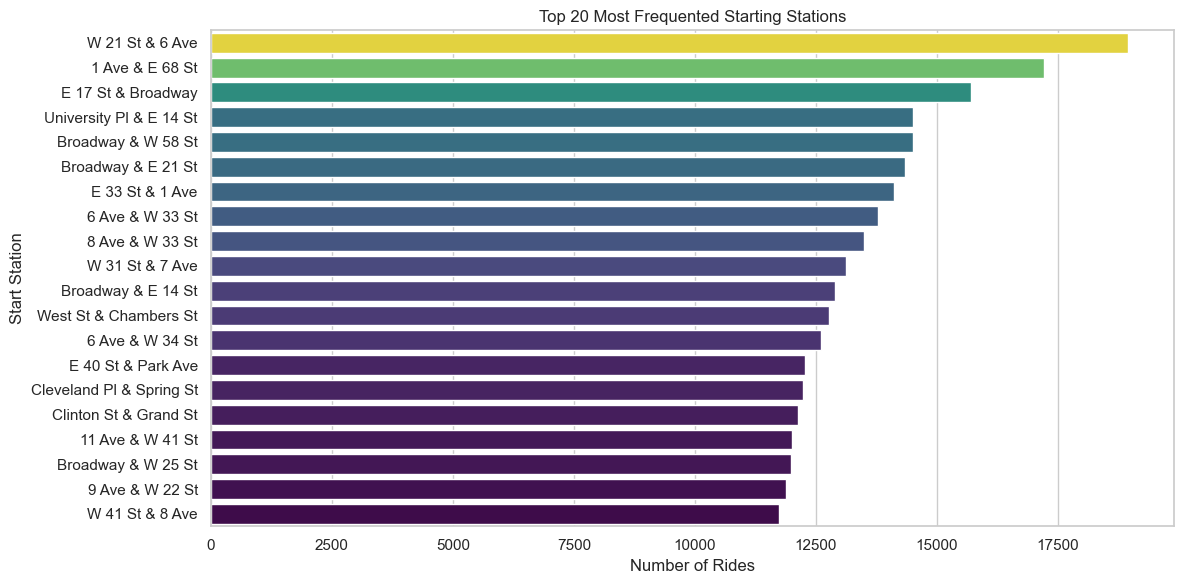

In [21]:
from matplotlib.cm import viridis
from matplotlib.colors import Normalize

# Get top 20 stations
top_starts = df['start_station_name'].value_counts().nlargest(20).reset_index()
top_starts.columns = ['start_station_name', 'count']

# Normalize for color mapping
norm = Normalize(vmin=top_starts['count'].min(), vmax=top_starts['count'].max())
colors = [plt.cm.viridis(norm(val)) for val in top_starts['count']]

# Plot with gradient
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_starts,
    x='count',
    y='start_station_name',
    palette=colors
)
plt.title('Top 20 Most Frequented Starting Stations')
plt.xlabel('Number of Rides')
plt.ylabel('Start Station')
plt.tight_layout()
plt.show
plt.savefig("Top 20 Most Frequented Starting Stations - seaborn horizontal bar chart")

# Dual-Axis Line Plot Trip Count & Temperature Over Time

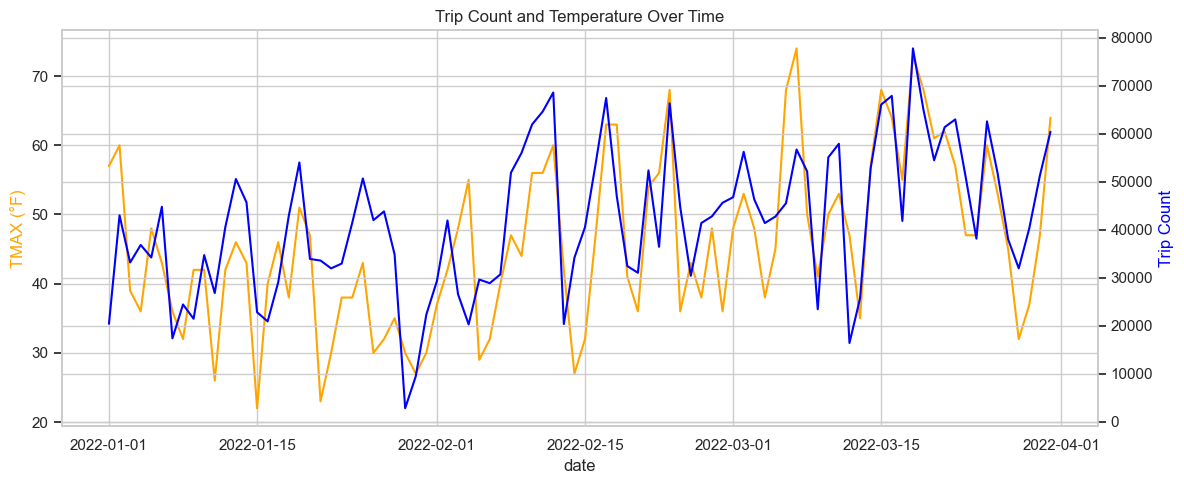

In [20]:
df_cleaned = df.dropna(subset=['date', 'TMAX'])
trip_counts = df_cleaned.groupby('date').size().reset_index(name='trip_count')
weather_df = df_cleaned[['date', 'TMAX']].drop_duplicates()
merged_df = pd.merge(trip_counts, weather_df, on='date').sort_values('date')

fig, ax1 = plt.subplots(figsize=(12, 5))

sns.lineplot(data=merged_df, x='date', y='TMAX', ax=ax1, color='orange')
ax1.set_ylabel('TMAX (°F)', color='orange')
ax2 = ax1.twinx()
sns.lineplot(data=merged_df, x='date', y='trip_count', ax=ax2, color='blue')
ax2.set_ylabel('Trip Count', color='blue')

plt.title('Trip Count and Temperature Over Time')
plt.tight_layout()
plt.show
plt.savefig("Trip Count and Temperature Over Time - seaborn dual axis line plot")

# Box Plot Duration by User Type

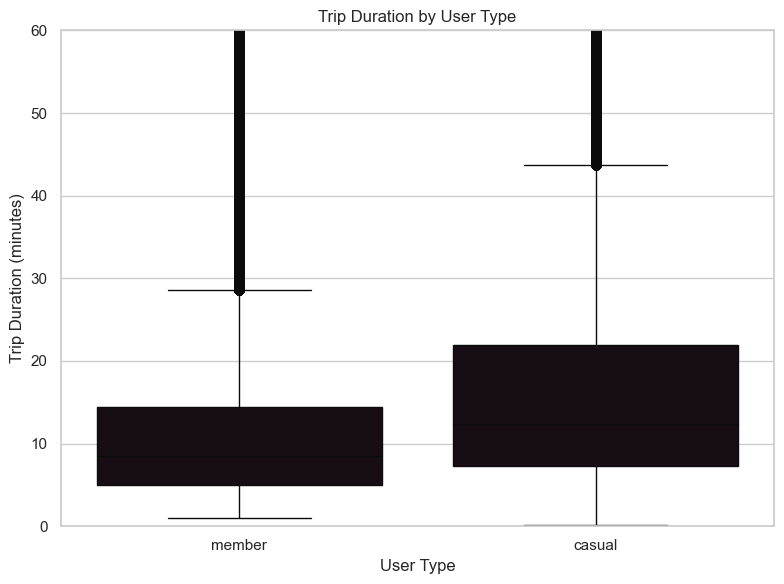

<Figure size 640x480 with 0 Axes>

In [19]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='member_casual', y='trip_duration_minutes')
plt.title('Trip Duration by User Type')
plt.xlabel('User Type')
plt.ylabel('Trip Duration (minutes)')
plt.ylim(0, 60)  # Trim extreme outliers
plt.tight_layout()
plt.show()
plt.savefig("Trip Duration by User Type - seaborn box plot")

The box plot shows that casual riders usually take longer bike trips than members.
Members tend to have shorter, more consistent ride times, likely using the bikes for quick trips or commuting.
Casual users, on the other hand, have more varied and often longer rides, suggesting they might be biking for fun or sightseeing.

# FacetGrid Trip Duration by Day of Week & User Type

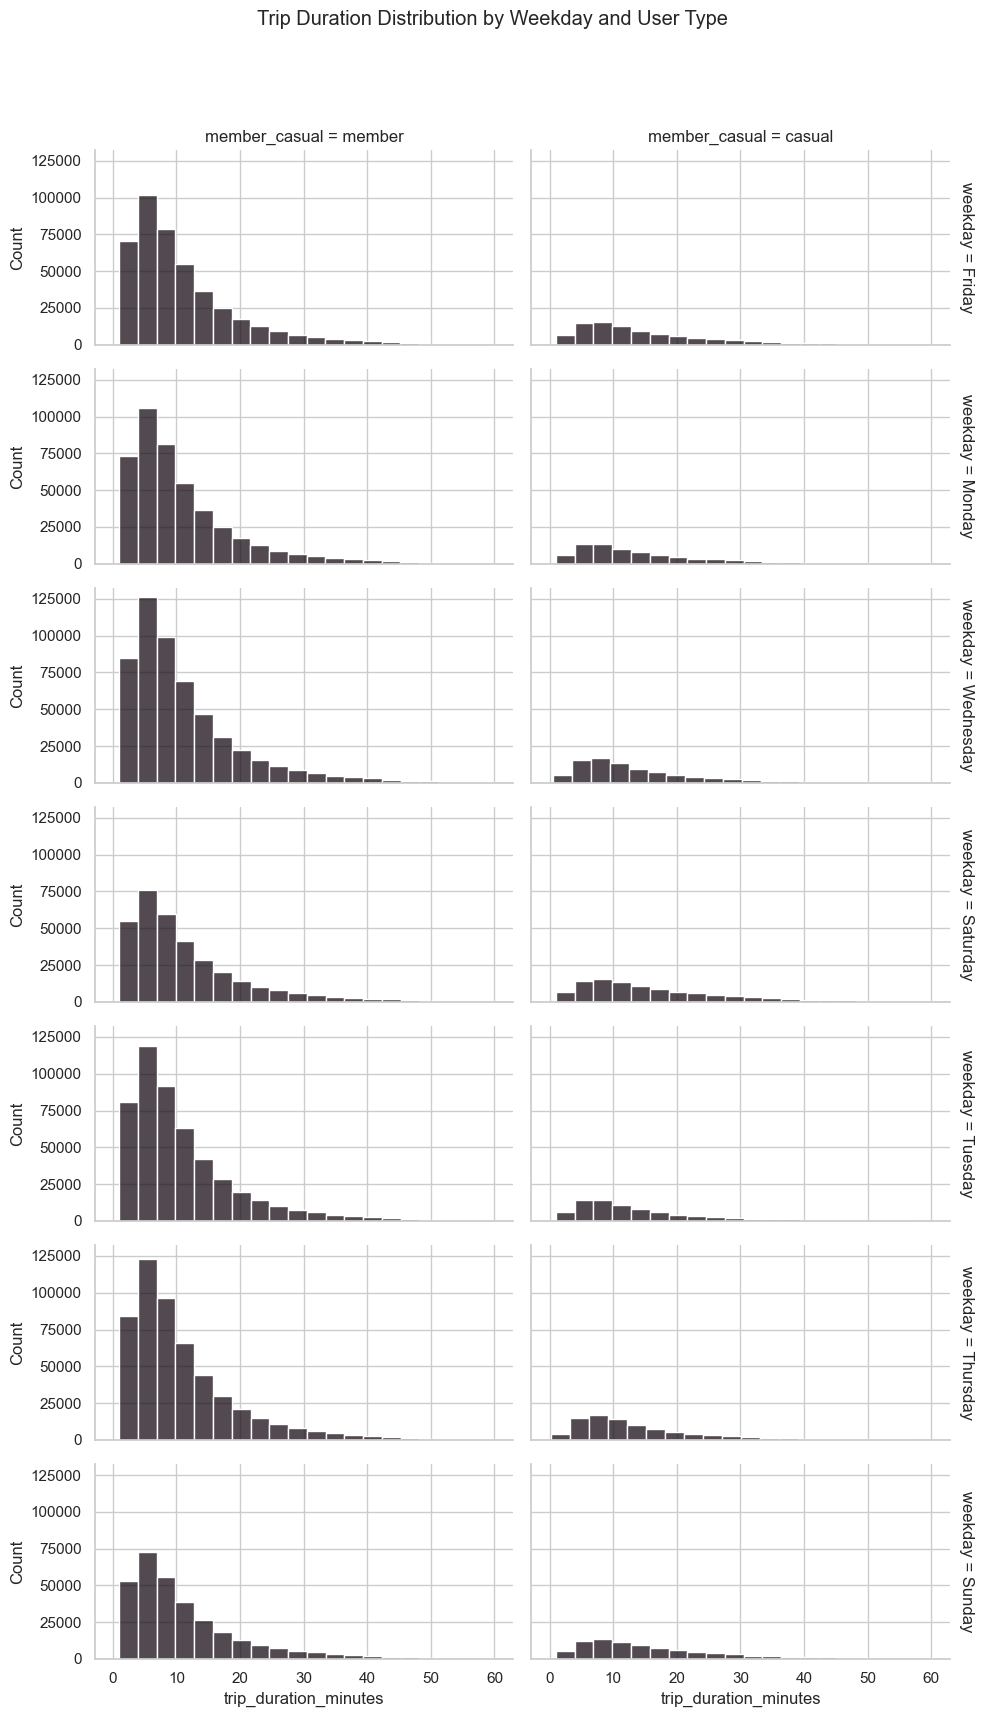

<Figure size 640x480 with 0 Axes>

In [22]:
# Add weekday column
df['weekday'] = df['started_at'].dt.day_name()

# Limit extreme durations for clarity
df_filtered = df[df['trip_duration_minutes'] < 60]

g = sns.FacetGrid(df_filtered, col='member_casual', row='weekday', margin_titles=True, height=2.5, aspect=2)
g.map(sns.histplot, 'trip_duration_minutes', bins=20)
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Trip Duration Distribution by Weekday and User Type')
plt.show()
plt.savefig("Trip Duration Distribution by Weekday and User Type - seaborn facetgrid")

The chart shows that members and casual riders use bikes differently during the week.
Members tend to take similar-length rides every day, likely for work or errands.
Casual riders, however, take much longer rides on weekends, which suggests they’re using the bikes more for fun or relaxation.